# Transit Level-of-Service walkthrough

This notebook demonstrates the end-to-end `transitlos` public API: define an
area of interest (AOI), compute a street-edges transit-level of service with a
single call to `transitlos.compute_level_of_service`, and inspect/plot the
result.

It reuses Cambridge, Massachusetts, USA as the example place, for continuity
with `pyGTFSHandler/examples/cambridge_massachusetts_usa_example.ipynb`
(which shows how to search/download a real GTFS feed for this city from the
Mobility Database) -- so the GTFS `feed_source` used below is a set of local
GTFS zip/directory paths obtained the same way that notebook obtains them.

This notebook calls out to the network (OSM PBF download via Geofabrik,
GTFS feed download via the Mobility Database), so it is not guaranteed to
run end-to-end in every environment. Each step is explained in its own
markdown cell; see `report/scoring/SCORING.md` for the scoring methodology
referenced along the way.


## 1. Imports

Only the top-level `transitlos` package is needed for this walkthrough --
`compute_level_of_service` is re-exported from `transitlos.api` (and from
`transitlos` itself), so callers don't need to know which submodule
implements it.


In [1]:
import matplotlib.pyplot as plt
import geopandas as gpd

import transitlos
from transitlos import compute_level_of_service
from UrbanAccessAnalyzer.api import AreaOfInterest


## 2. Define the area of interest

`transitlos.compute_level_of_service` takes an `AreaOfInterest` (from
`UrbanAccessAnalyzer.api`), which just wraps a polygon GeoDataFrame. Here we
build one for Cambridge, MA -- the same city used in the pyGTFSHandler
example notebook, via `pyGTFSHandler.utils.geocoding.get_city_geometry`, so
that the AOI and the GTFS feed we download below cover the same place.


Text(0.5, 1.0, 'Cambridge, Massachusetts, USA')

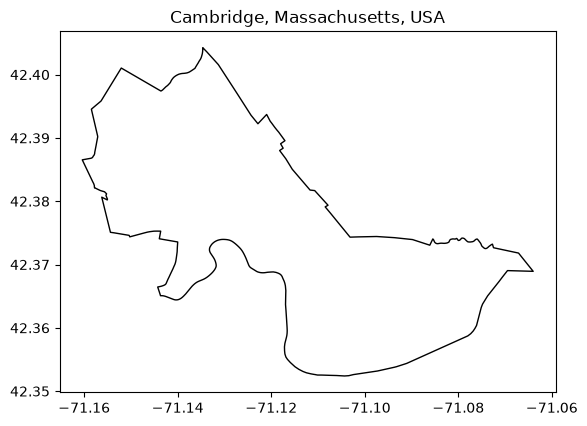

In [2]:
from pyGTFSHandler.utils.geocoding import get_city_geometry

city_name = "Cambridge, Massachusetts, USA"
city_gdf = get_city_geometry(city_name)  # returns a single-row polygon GeoDataFrame
aoi = AreaOfInterest(city_gdf)
city_gdf.plot(edgecolor="black", facecolor="none")
plt.title(city_name)


## 3. Get a GTFS feed source

`feed_source` is passed straight through to `pyGTFSHandler.feed.Feed`, so any
path/URL/list of GTFS zip or directory paths it understands works. The
pyGTFSHandler Cambridge example notebook shows how to search and download a
real feed for this city from the Mobility Database
(`MobilityDatabaseDownloader.search_feeds` + `.download_feeds`, which
requires a free API token) -- reuse that same downloaded path list here.


In [3]:
# Reuse the same Mobility Database search/download flow as the
# pyGTFSHandler Cambridge example notebook (see its "2. Download GTFS
# feeds" section) so this notebook is runnable standalone.
import glob

from pyGTFSHandler.utils.geocoding import get_geographic_suggestions_from_string
from pyGTFSHandler.downloaders.mobility_database import MobilityDatabaseDownloader

geo_suggestions = get_geographic_suggestions_from_string(city_name)

# Leave the refresh token empty to read it from api_keys.json instead (see
# api_keys.example.json at the pyGTFSHandler repo root -- looked up in the
# current working directory or any of its parents).
api = MobilityDatabaseDownloader("")
feeds = api.search_feeds(
    country_code=geo_suggestions["country_codes"],
    subdivision_name=geo_suggestions["subdivision_names"],
    municipality=geo_suggestions["municipalities"],
    is_official=True,
)
orig_file_paths = api.download_feeds(
    feeds=feeds,
    download_folder="outputs/orig_gtfs_files",
    overwrite=False,
)

feed_source = sorted(glob.glob("outputs/orig_gtfs_files/*"))
feed_source


['outputs/orig_gtfs_files/mdb-11_amtrak',
 'outputs/orig_gtfs_files/mdb-433_montachuse',
 'outputs/orig_gtfs_files/mdb-437_massachuse',
 'outputs/orig_gtfs_files/mdb-439_metrowest',
 'outputs/orig_gtfs_files/mdb-440_128_busine',
 'outputs/orig_gtfs_files/mdb-441_massport',
 'outputs/orig_gtfs_files/mdb-442_middlesex',
 'outputs/orig_gtfs_files/mdb-444_lowell_reg',
 'outputs/orig_gtfs_files/mdb-445_merrimack',
 'outputs/orig_gtfs_files/mdb-496_peter_pan',
 'outputs/orig_gtfs_files/tld-4462_harvard_un']

## 4. Compute the level-of-service layer

`transitlos.level_of_service.compute_level_of_service` is the "do everything"
entry point: it builds (or loads a cached) walking street network via
`transitlos.network.prepare_street_network`, loads and scores the GTFS stops
via `transitlos.stops.download_and_prepare_stops` +
`transitlos.stop_scores.compute_stop_scores`, and runs an
`UrbanAccessAnalyzer.api.AccessibilityAnalyzer` to produce a street-edges
GeoDataFrame with an `level_of_service` column.

`region="north_america"` selects the regional scoring parameter table for
the stop-quality sub-scores (mode/speed, frequency, reliability) -- see
`report/scoring/SCORING.md` section 3.2 ("North America (US/Canada)"). The
`pbf_path` must point at a local `.osm.pbf` covering the AOI (downloaded from
Geofabrik automatically if the file doesn't exist yet); `cache_dir` lets the
simplified network be reused across runs instead of rebuilt every time.


**Skipping the expensive auto-date-detection.** If `date_range` isn't
passed, `download_and_prepare_stops` auto-detects a representative service
day via `Feed.get_representative_date`: dates are grouped into calendar
(Monday-Sunday) weeks, each week is scored by its **median** daily service
intensity (so one anomalous day doesn't skew which week looks best), the
highest-scoring week is picked, and within that week the specific weekday
returned is the one whose intensity is **closest to that week's weekday
median** (i.e. the "typical" day of the best week, not the busiest or
quietest one) -- see
`pyGTFSHandler.utils.processing_helpers.select_representative_date` for the
full algorithm and its documented edge-case handling (partial boundary
weeks, holiday exclusion). This auto-detection is a safe default, but on
this real multi-feed Cambridge, MA GTFS set (11 feeds under
`outputs/orig_gtfs_files/`) it costs several seconds of `compute_level_of_service`'s
runtime. We already know a good date from running that same auto-detection
once here: it picked **Friday, 2026-08-21** (a normal MBTA weekday service
day, well within `mdb-437_massachuse`'s `calendar.txt` weekday range of
2026-07-31 to 2026-09-05). Passing `date_range=(that_date, that_date)`
explicitly below skips the auto-detection step entirely -- the cell after it
demonstrates the auto-detection path for real, without an explicit date.


In [4]:
from datetime import date

# Explicit, known-good service date (see markdown note above) -- skips
# download_and_prepare_stops's ~7s auto-detection fallback.
analysis_date = date(2026, 8, 21)

access_gdf = compute_level_of_service(
    aoi,
    feed_source=feed_source,
    region="north_america",
    cache_dir="./_network_cache",
    pbf_path="./us_massachusetts.osm.pbf",
    walk_distance_steps=(400, 800, 1200),
    date_range=(analysis_date, analysis_date),
)
access_gdf.head()


/home/miguel/Documents/Proyectos/AccessibilityMIT/pyGTFSHandler/pyGTFSHandler/models/stop_times.py:199: UserWarning: Some departure times are null and have been interpolated
  warnings.warn("Some departure times are null and have been interpolated")


/home/miguel/Documents/Proyectos/AccessibilityMIT/pyGTFSHandler/pyGTFSHandler/models/shapes.py:1325: RuntimeWarning: direction_id assignment: 1 of 132 shape_ids (0.8%) had at least one stop where the geometry disagreed with their reported direction_id (direction_conflict=True), across 1 of 302 stop(s) (0.3%).
  warnings.warn(


[isochrones] tier level_of_service=0.992 distance=400.0 n_sources=4
[isochrones] tier level_of_service=0.987 distance=800.0 n_sources=4
[isochrones] tier level_of_service=0.982 distance=1200.0 n_sources=4
[isochrones] tier level_of_service=0.972 distance=400.0 n_sources=5
[isochrones] tier level_of_service=0.967 distance=800.0 n_sources=5
[isochrones] tier level_of_service=0.962 distance=1200.0 n_sources=5
[isochrones] tier level_of_service=0.952 distance=400.0 n_sources=4
[isochrones] tier level_of_service=0.947 distance=800.0 n_sources=4
[isochrones] tier level_of_service=0.942 distance=1200.0 n_sources=4
[isochrones] tier level_of_service=0.932 distance=400.0 n_sources=4
[isochrones] tier level_of_service=0.927 distance=800.0 n_sources=4
[isochrones] tier level_of_service=0.922 distance=1200.0 n_sources=4
[isochrones] tier level_of_service=0.912 distance=400.0 n_sources=4
[isochrones] tier level_of_service=0.907 distance=800.0 n_sources=4
[isochrones] tier level_of_service=0.902 dis

,u,v,length_m,highway,edge_uid,oneway,level_of_service,geometry
0,61317367.0,NaN,13.116382,residential,541,True,0.992,"LINESTRING (326941.267 4692809.478, 326953.547..."
1,61317413.0,NaN,30.366023,residential,553,False,0.992,"LINESTRING (326499.372 4692982.975, 326522.226..."
2,61321194.0,NaN,85.550940,residential,554,True,0.992,"LINESTRING (326439.457 4692921.907, 326499.372..."
3,61317416.0,NaN,42.260110,residential,555,False,0.992,"LINESTRING (326961.929 4692659.775, 326999.752..."
4,61328503.0,NaN,71.699954,residential,556,True,0.992,"LINESTRING (326927.048 4692597.131, 326961.929..."


**Exercising the smart auto-detection fallback for real.** The cell below omits `date_range` entirely, so `download_and_prepare_stops` runs the new `Feed.get_representative_date` algorithm against the real cached Cambridge feeds end-to-end (rather than reusing the pre-computed date above). We keep both cells in the notebook: the explicit-date cell demonstrates the fast path, and this one demonstrates the smart-fallback path that callers get when they don't already know a good date.

In [5]:
# No date_range given -- exercises the new week-median /
# closest-to-median-weekday `get_representative_date` fallback end-to-end
# against the real cached Cambridge, MA GTFS feeds.
access_gdf_auto = compute_level_of_service(
    aoi,
    feed_source=feed_source,
    region="north_america",
    cache_dir="./_network_cache",
    pbf_path="./us_massachusetts.osm.pbf",
    walk_distance_steps=(400, 800, 1200),
)
access_gdf_auto["level_of_service"].describe()

/home/miguel/Documents/Proyectos/AccessibilityMIT/pyGTFSHandler/pyGTFSHandler/models/stop_times.py:199: UserWarning: Some departure times are null and have been interpolated
  warnings.warn("Some departure times are null and have been interpolated")


/home/miguel/Documents/Proyectos/AccessibilityMIT/pyGTFSHandler/pyGTFSHandler/models/shapes.py:1325: RuntimeWarning: direction_id assignment: 4 of 228 shape_ids (1.8%) had at least one stop where the geometry disagreed with their reported direction_id (direction_conflict=True), across 3 of 333 stop(s) (0.9%).
  warnings.warn(


[isochrones] tier level_of_service=0.993 distance=400.0 n_sources=4
[isochrones] tier level_of_service=0.988 distance=800.0 n_sources=4
[isochrones] tier level_of_service=0.983 distance=1200.0 n_sources=4
[isochrones] tier level_of_service=0.973 distance=400.0 n_sources=5
[isochrones] tier level_of_service=0.968 distance=800.0 n_sources=5
[isochrones] tier level_of_service=0.963 distance=1200.0 n_sources=5
[isochrones] tier level_of_service=0.953 distance=400.0 n_sources=4
[isochrones] tier level_of_service=0.948 distance=800.0 n_sources=4
[isochrones] tier level_of_service=0.943 distance=1200.0 n_sources=4
[isochrones] tier level_of_service=0.933 distance=400.0 n_sources=5
[isochrones] tier level_of_service=0.928 distance=800.0 n_sources=5
[isochrones] tier level_of_service=0.923 distance=1200.0 n_sources=5
[isochrones] tier level_of_service=0.913 distance=400.0 n_sources=5
[isochrones] tier level_of_service=0.908 distance=800.0 n_sources=5
[isochrones] tier level_of_service=0.903 dis

count    34259.000000
mean         0.841396
std          0.206153
min          0.112000
25%          0.823000
50%          0.948000
75%          0.983000
max          0.993000
Name: level_of_service, dtype: float64

## 5. Inspect and plot the `level_of_service` distribution

`level_of_service` is defined per street edge, already decayed by walking
distance to the nearest well-served stop (see the module docstring of
`transitlos.level_of_service` and `report/scoring/SCORING.md` section 1.2,
"Accessibility score", for how the distance/stop-quality tiers combine).
Higher is better access.


In [6]:
access_gdf["level_of_service"].describe()


count    34130.000000
mean         0.842410
std          0.183563
min          0.113000
25%          0.807000
50%          0.892000
75%          0.982000
max          0.992000
Name: level_of_service, dtype: float64

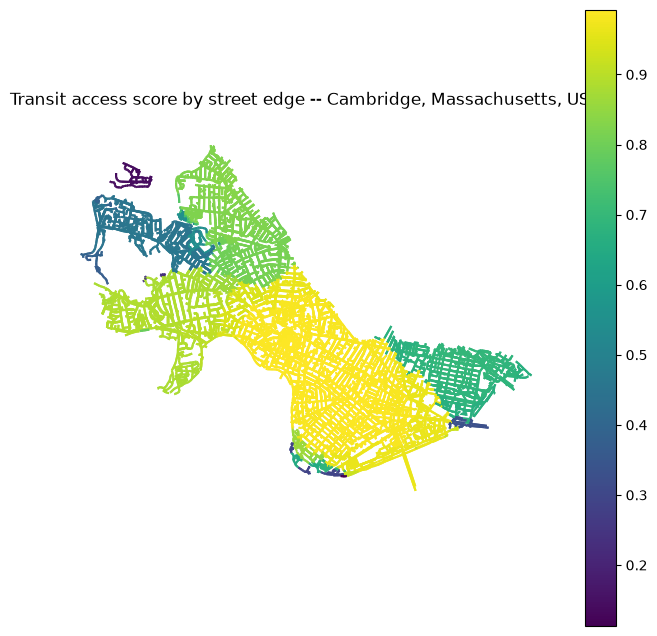

In [7]:
fig, ax = plt.subplots(figsize=(8, 8))
access_gdf.plot(
    column="level_of_service",
    cmap="viridis",
    legend=True,
    ax=ax,
    linewidth=1.5,
)
ax.set_title(f"Transit level of service by street edge -- {city_name}")
ax.set_axis_off()


## Next steps

The `access_gdf` produced here (or a freshly recomputed one) is the input to
the equity analysis in `equity_analysis_walkthrough.ipynb`, which joins
population data onto it via `transitlos.cross_with_population` and computes
population-weighted equity statistics via `transitlos.equity_statistics`.
